# **FMCG Sales Analysis and Visualization**

**Project Overview**
This project aims to forecast sales units for Fast-Moving Consumer Goods (FMCG) across various stores and countries for 3 years. By leveraging historical sales data, weather information, and promotional flags, we build predictive models to optimize inventory and supply chain management.

**Dataset**

The dataset used is fmcg_sales_3years_1M_rows.csv, containing approximately 1.1 million rows of sales transactions. Key columns include:

**date:** Date of the transaction.

**year, month, day, weekofyear, weekday:** Time-based features.

**is_weekend, is_holiday**: Binary flags for weekends and holidays.

**temperature, rain_mm:** Environmental factors.

**store_id, country, city, channel:** Location and sales channel information.

**sku_id, sku_name, category, subcategory, brand:** Product identifiers and classifications.

**units_sold, list_price, discount_pct, promo_flag:** Sales and pricing details.

**gross_sales, net_sales:** Revenue figures.

**stock_on_hand, stock_out_flag, lead_time_days, supplier_id, purchase_cost, margin_pct:** Inventory and cost details.




In [1]:
# Importing libabries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
from sklearn.model_selection import train_test_split

In [2]:
# Opening the dataframe
FMCG_df = pd.read_csv('fmcg_sales_3years_1M_rows.csv')

# Set max columns
pd.set_option("display.max_columns", None)

# Displaying the first 5 rows
FMCG_df.head()

,date,year,month,day,weekofyear,weekday,is_weekend,is_holiday,temperature,rain_mm,store_id,country,city,channel,latitude,longitude,sku_id,sku_name,category,subcategory,brand,units_sold,list_price,discount_pct,promo_flag,gross_sales,net_sales,stock_on_hand,stock_out_flag,lead_time_days,supplier_id,purchase_cost,margin_pct
0,2021-01-01,2021,1,1,53,4,0,1,8.44,1.24,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,16,10.49,0.1,1,167.84,151.06,248,0,11,S008,7.53,0.182
1,2021-01-02,2021,1,2,53,5,1,0,12.61,1.12,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,12,10.49,0.0,0,125.88,125.88,238,0,6,S057,5.19,0.505
2,2021-01-03,2021,1,3,53,6,1,0,12.02,2.69,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,38,10.49,0.3,1,398.62,279.03,238,0,6,S017,5.59,0.168
3,2021-01-04,2021,1,4,1,0,0,0,7.76,4.65,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,8,10.49,0.0,0,83.92,83.92,216,0,7,S012,7.81,0.255
4,2021-01-05,2021,1,5,1,1,0,0,11.16,1.77,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,17,10.49,0.2,1,178.33,142.66,372,0,8,S038,7.62,0.073


**Exploratory Data Analysis**

In [3]:
# Displaying the information content in the dataframe
FMCG_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100000 entries, 0 to 1099999
Data columns (total 33 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   date            1100000 non-null  object 
 1   year            1100000 non-null  int64  
 2   month           1100000 non-null  int64  
 3   day             1100000 non-null  int64  
 4   weekofyear      1100000 non-null  int64  
 5   weekday         1100000 non-null  int64  
 6   is_weekend      1100000 non-null  int64  
 7   is_holiday      1100000 non-null  int64  
 8   temperature     1100000 non-null  float64
 9   rain_mm         1100000 non-null  float64
 10  store_id        1100000 non-null  object 
 11  country         1100000 non-null  object 
 12  city            1100000 non-null  object 
 13  channel         1100000 non-null  object 
 14  latitude        1100000 non-null  float64
 15  longitude       1100000 non-null  float64
 16  sku_id          1100000 non-null  ob

In [4]:
# Displaying the number of rows and columns in the dataframe
FMCG_df.shape

(1100000, 33)

In [5]:
# Displaying if there is any missing value in the dataframe
FMCG_df.isnull().sum()

date              0
year              0
month             0
day               0
weekofyear        0
weekday           0
is_weekend        0
is_holiday        0
temperature       0
rain_mm           0
store_id          0
country           0
city              0
channel           0
latitude          0
longitude         0
sku_id            0
sku_name          0
category          0
subcategory       0
brand             0
units_sold        0
list_price        0
discount_pct      0
promo_flag        0
gross_sales       0
net_sales         0
stock_on_hand     0
stock_out_flag    0
lead_time_days    0
supplier_id       0
purchase_cost     0
margin_pct        0
dtype: int64

In [6]:
# Displaying the summary statistics
FMCG_df.describe()

,year,month,day,weekofyear,weekday,is_weekend,is_holiday,temperature,rain_mm,latitude,longitude,units_sold,list_price,discount_pct,promo_flag,gross_sales,net_sales,stock_on_hand,stock_out_flag,lead_time_days,purchase_cost,margin_pct
count,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06
mean,2.022000e+03,6.525613e+00,1.572044e+01,2.657081e+01,3.005479e+00,2.867582e-01,1.369818e-02,1.281501e+01,2.904106e+00,4.630581e+01,9.030856e+00,5.919635e+01,7.712100e+00,1.496241e-02,8.023364e-02,4.406806e+02,4.299513e+02,2.994757e+02,3.010364e-02,6.500404e+00,4.625546e+00,3.852405e-01
std,8.164700e-01,3.447760e+00,8.796262e+00,1.505126e+01,2.000451e+00,4.522478e-01,1.162349e-01,3.371587e+00,2.098997e+00,4.602927e+00,6.727444e+00,4.500722e+01,4.253023e+00,5.477955e-02,2.716547e-01,4.418005e+02,4.224992e+02,8.007292e+01,1.708726e-01,2.014065e+00,2.662604e+00,1.024581e-01
min,2.021000e+03,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.800000e+00,0.000000e+00,4.041706e+01,-3.674730e+00,0.000000e+00,1.080000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,4.900000e-01,-5.000000e-02
25%,2.021000e+03,4.000000e+00,8.000000e+00,1.400000e+01,1.000000e+00,0.000000e+00,0.000000e+00,1.061000e+01,1.220000e+00,4.190833e+01,2.360460e+00,2.500000e+01,4.200000e+00,0.000000e+00,0.000000e+00,1.324400e+02,1.307675e+02,2.450000e+02,0.000000e+00,5.000000e+00,2.400000e+00,3.120000e-01
50%,2.022000e+03,7.000000e+00,1.600000e+01,2.700000e+01,3.000000e+00,0.000000e+00,0.000000e+00,1.284000e+01,2.570000e+00,4.546266e+01,9.203130e+00,4.900000e+01,7.380000e+00,0.000000e+00,0.000000e+00,2.828800e+02,2.778600e+02,3.000000e+02,0.000000e+00,6.000000e+00,4.350000e+00,3.890000e-01
75%,2.023000e+03,1.000000e+01,2.300000e+01,4.000000e+01,5.000000e+00,1.000000e+00,0.000000e+00,1.500000e+01,4.150000e+00,5.225287e+01,1.339071e+01,8.200000e+01,1.165000e+01,0.000000e+00,0.000000e+00,6.052800e+02,5.934600e+02,3.540000e+02,0.000000e+00,8.000000e+00,6.770000e+00,4.690000e-01
max,2.023000e+03,1.200000e+01,3.100000e+01,5.300000e+01,6.000000e+00,1.000000e+00,1.000000e+00,2.283000e+01,1.158000e+01,5.252586e+01,2.099579e+01,7.040000e+02,1.480000e+01,3.000000e-01,1.000000e+00,6.593900e+03,5.144940e+03,6.980000e+02,1.000000e+00,1.700000e+01,1.110000e+01,5.500000e-01


In [7]:
# Displaying the first 10 rows of the dataframe
FMCG_df.head(10)

,date,year,month,day,weekofyear,weekday,is_weekend,is_holiday,temperature,rain_mm,store_id,country,city,channel,latitude,longitude,sku_id,sku_name,category,subcategory,brand,units_sold,list_price,discount_pct,promo_flag,gross_sales,net_sales,stock_on_hand,stock_out_flag,lead_time_days,supplier_id,purchase_cost,margin_pct
0,2021-01-01,2021,1,1,53,4,0,1,8.44,1.24,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,16,10.49,0.10,1,167.84,151.06,248,0,11,S008,7.53,0.182
1,2021-01-02,2021,1,2,53,5,1,0,12.61,1.12,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,12,10.49,0.00,0,125.88,125.88,238,0,6,S057,5.19,0.505
2,2021-01-03,2021,1,3,53,6,1,0,12.02,2.69,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,38,10.49,0.30,1,398.62,279.03,238,0,6,S017,5.59,0.168
3,2021-01-04,2021,1,4,1,0,0,0,7.76,4.65,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,8,10.49,0.00,0,83.92,83.92,216,0,7,S012,7.81,0.255
4,2021-01-05,2021,1,5,1,1,0,0,11.16,1.77,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,17,10.49,0.20,1,178.33,142.66,372,0,8,S038,7.62,0.073
5,2021-01-06,2021,1,6,1,2,0,0,13.29,1.46,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,11,10.49,0.00,0,115.39,115.39,353,0,4,S017,5.35,0.490
6,2021-01-07,2021,1,7,1,3,0,0,6.19,11.58,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,15,10.49,0.20,1,157.35,125.88,183,0,9,S003,7.19,0.115
7,2021-01-08,2021,1,8,1,4,0,0,13.00,2.90,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,8,10.49,0.00,0,83.92,83.92,239,0,5,S007,6.78,0.354
8,2021-01-09,2021,1,9,1,5,1,0,9.56,0.26,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,15,10.49,0.15,1,157.35,133.75,272,0,8,S039,5.38,0.337
9,2021-01-10,2021,1,10,1,6,1,0,13.42,0.72,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,17,10.49,0.10,1,178.33,160.50,250,0,7,S028,6.99,0.234


# Total sales by country

In [8]:
# Creating a df that has country, and net sales for the FMCG
countries = FMCG_df.groupby("country")["net_sales"].sum().reset_index()
countries

,country,net_sales
0,Austria,4.302003e+07
1,France,4.260161e+07
2,Germany,8.852556e+07
3,Italy,1.371931e+08
4,Netherlands,1.251615e+07
5,Poland,4.238526e+07
6,Spain,1.067048e+08


In [9]:
# Changing the net sales to millions by dividing by 1,000,000
countries["net_sales"] = countries["net_sales"]/1000000
countries.sort_values(by="net_sales", ascending=False, inplace=True)
countries

,country,net_sales
3,Italy,137.193076
6,Spain,106.704767
2,Germany,88.525559
0,Austria,43.020026
1,France,42.601613
5,Poland,42.385263
4,Netherlands,12.516150


In [10]:
# Displaying the countries table
countries

,country,net_sales
3,Italy,137.193076
6,Spain,106.704767
2,Germany,88.525559
0,Austria,43.020026
1,France,42.601613
5,Poland,42.385263
4,Netherlands,12.516150


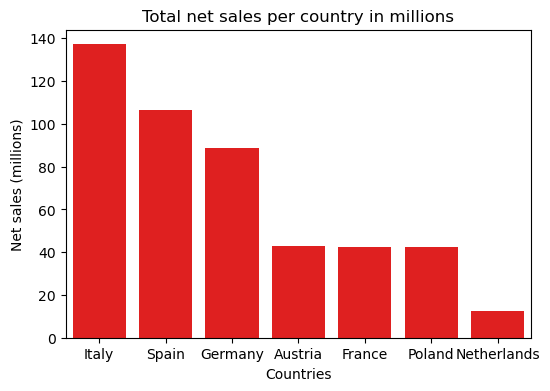

In [12]:
# Ploting a bar grapph showing the net sales per country
plt.figure(figsize =(6,4))
sns.barplot(x="country", y="net_sales", data=countries, color='red')
plt.title("Total net sales per country in millions")
plt.xlabel("Countries")
plt.ylabel("Net sales (millions)")
plt.savefig("Outputs/Total sales (millions).png") # Saving the table as a png
plt.show()

**INSIGHTS**

We see that **Italy** generates more revenue with **Netherlands** generating the least. *More than half* of the countries have very low revenue this is due to overtocking goods.

# Top 20 SKUs by revenue (net sales)

In [13]:
# Creating a df for the SKUs that has the sku name, net sales and units sold
SKUs = FMCG_df.groupby("sku_name")[["net_sales","units_sold"]].sum().reset_index()
SKUs.head(10)

,sku_name,net_sales,units_sold
0,BrandA Biscuits,1095936.48,1014756
1,BrandA Cheese,11967260.40,972948
2,BrandA Chips,2504304.75,289515
3,BrandA Chocolate,2861354.90,474919
4,BrandA Cleaner,5929387.53,607389
5,BrandA Detergent,1042152.84,388863
6,BrandA Energy drink,1145233.01,232121
7,BrandA Juice,4294839.45,339513
8,BrandA Milk,766537.80,182509
9,BrandA Nuts,2254584.27,449437


In [14]:
## Sorting the SKUs by units sold in descending order
SKUs_sorted = SKUs.sort_values(by=["units_sold"],ascending= False)
SKUs_sorted

,sku_name,net_sales,units_sold
12,BrandA Soda,10515682.83,1792381
97,BrandF Soda,2019134.87,1662175
71,BrandE Chocolate,2969636.16,1455704
96,BrandF Soap,2958329.00,1286230
53,BrandD Chips,11749108.59,1253907
...,...,...,...
11,BrandA Soap,872478.81,161607
49,BrandC Water,1435332.87,154503
27,BrandB Shampoo,1059653.35,107593
13,BrandA Softener,447233.74,89626


In [15]:
# Selecting the top 20 SKUs only
Top20_SKUs = SKUs_sorted.iloc[:20].reset_index(drop=True)
Top20_SKUs


,sku_name,net_sales,units_sold
0,BrandA Soda,10515682.83,1792381
1,BrandF Soda,2019134.87,1662175
2,BrandE Chocolate,2969636.16,1455704
3,BrandF Soap,2958329.00,1286230
4,BrandD Chips,11749108.59,1253907
5,BrandE Water,2225706.15,1243211
6,BrandC Toothpaste,12968809.43,1242389
7,BrandC Chips,16000295.02,1200897
8,BrandD Chocolate,3316591.88,1190066
9,BrandF Water,17032424.64,1173032


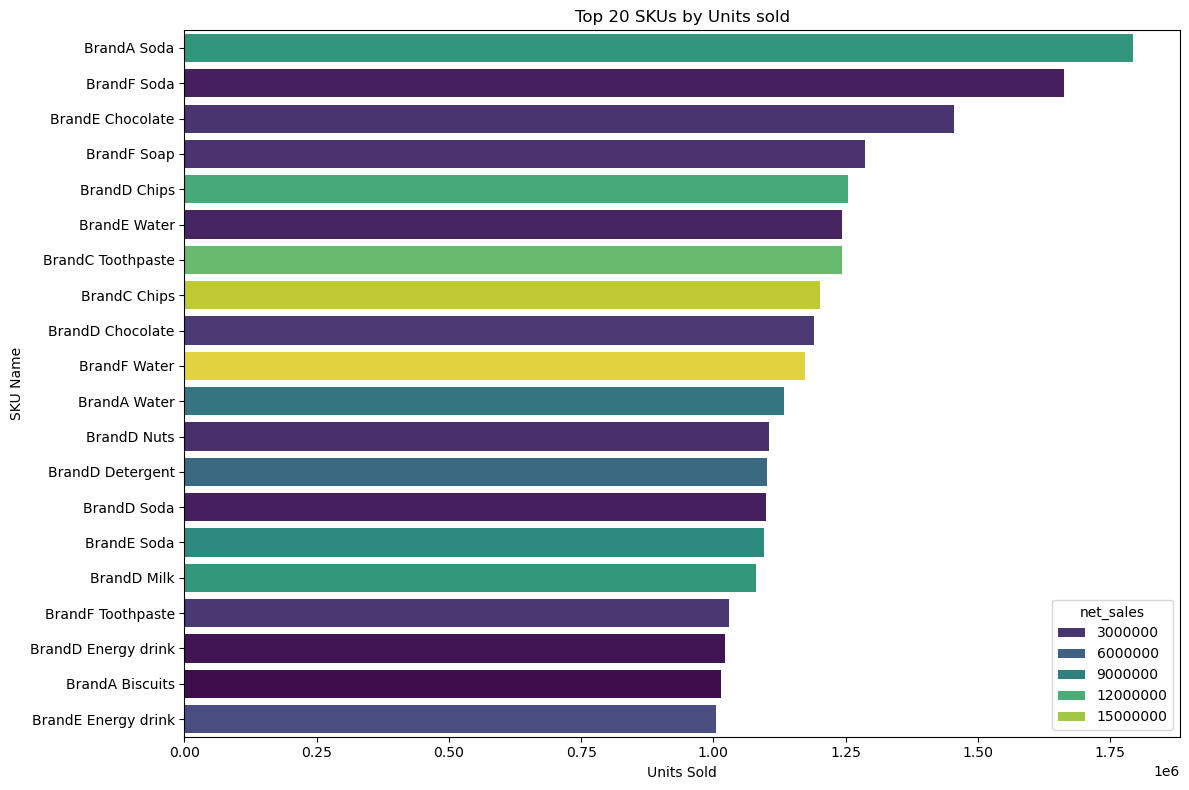

In [17]:
#Visualizing the top 20 SKUs againts the units sold and the revenue they bring to the business
plt.figure(figsize=(12, 8))
sns.barplot(x='units_sold', y='sku_name',hue='net_sales', data=Top20_SKUs, palette='viridis')
plt.title('Top 20 SKUs by Units sold')
plt.xlabel('Units Sold')
plt.ylabel('SKU Name')
plt.tight_layout()
plt.savefig("Outputs/Top 20 SKUs by Units sold.png")
plt.show()

**INSIGHTS**

 From the top 20 SKUs very few impact the revenue fully, there are skus that bring less revenue even when they are sold more and those that bring more revenue when only few units are sold.

**Brand F Soda** contributes a revenue of **30M** when more units are sold while **Brand C Chips** and **Brand F Water** contributes almost **150M** and the units sold are few.

# ABC Classification analysis per region

In [29]:
# Displaying the SKU names
FMCG_df['sku_name']

0           BrandB Shampoo
1           BrandB Shampoo
2           BrandB Shampoo
3           BrandB Shampoo
4           BrandB Shampoo
                ...       
1099995    BrandA Softener
1099996    BrandA Softener
1099997    BrandA Softener
1099998    BrandA Softener
1099999    BrandA Softener
Name: sku_name, Length: 1100000, dtype: object

In [30]:
# Calculate Revenue per SKU per Country
regional_revenue = FMCG_df.groupby(['country','sku_id','sku_name'])['net_sales'].sum().reset_index()
regional_revenue.head(10)


,country,sku_id,sku_name,net_sales
0,Austria,SKU0001,BrandA Soda,946219.91
1,Austria,SKU0002,BrandB Soda,987187.50
2,Austria,SKU0003,BrandC Soda,93768.66
3,Austria,SKU0004,BrandD Soda,223676.18
4,Austria,SKU0005,BrandE Soda,1060811.66
5,Austria,SKU0006,BrandF Soda,196630.52
6,Austria,SKU0007,BrandA Juice,465342.90
7,Austria,SKU0008,BrandB Juice,117249.40
8,Austria,SKU0009,BrandC Juice,418264.68
9,Austria,SKU0010,BrandD Juice,378376.46


In [31]:
# Sort by country and revenue to prepare for cumulative sum
regional_revenue = regional_revenue.sort_values(['country','net_sales'], ascending=[True,False]).reset_index(drop=True)
regional_revenue.head(10)

,country,sku_id,sku_name,net_sales
0,Austria,SKU0027,BrandC Chips,1881904.66
1,Austria,SKU0018,BrandF Water,1690621.68
2,Austria,SKU0092,BrandB Soap,1582125.30
3,Austria,SKU0057,BrandC Milk,1448420.22
4,Austria,SKU0061,BrandA Cheese,1415742.30
5,Austria,SKU0099,BrandC Toothpaste,1405907.73
6,Austria,SKU0100,BrandD Toothpaste,1360224.36
7,Austria,SKU0064,BrandD Cheese,1345919.70
8,Austria,SKU0041,BrandE Biscuits,1246102.83
9,Austria,SKU0028,BrandD Chips,1156970.12


In [32]:
# Calculating Cumulative Revenue Percentage for each country
regional_revenue['cum_rev_country'] = regional_revenue.groupby('country')['net_sales'].cumsum()

# Calculating the total revenue per country
regional_revenue['total_rev_country'] = regional_revenue.groupby('country')['net_sales'].transform('sum')

# Calculating the percent revenue per SKU per country
regional_revenue['rev_pct'] = regional_revenue['cum_rev_country'] / regional_revenue['total_rev_country'] *100

regional_revenue

,country,sku_id,sku_name,net_sales,cum_rev_country,total_rev_country,rev_pct
0,Austria,SKU0027,BrandC Chips,1881904.66,1.881905e+06,4.302003e+07,4.374485
1,Austria,SKU0018,BrandF Water,1690621.68,3.572526e+06,4.302003e+07,8.304333
2,Austria,SKU0092,BrandB Soap,1582125.30,5.154652e+06,4.302003e+07,11.981982
3,Austria,SKU0057,BrandC Milk,1448420.22,6.603072e+06,4.302003e+07,15.348833
4,Austria,SKU0061,BrandA Cheese,1415742.30,8.018814e+06,4.302003e+07,18.639724
...,...,...,...,...,...,...,...
580,Spain,SKU0029,BrandE Chips,126754.01,1.063815e+08,1.067048e+08,99.697091
581,Spain,SKU0040,BrandD Biscuits,107463.63,1.064890e+08,1.067048e+08,99.797803
582,Spain,SKU0051,BrandC Yogurt,103232.16,1.065922e+08,1.067048e+08,99.894548
583,Spain,SKU0050,BrandB Yogurt,68680.00,1.066609e+08,1.067048e+08,99.958913


In [33]:
# Assign ABC Classes based on regional performance
def assign_abc(pct):
    if pct <= 70: return 'A' # High Value - require strict control
    elif pct <= 90: return 'B' # Moderate Value - moderate control
    else: return 'C' # Low Value - minimal control

regional_revenue['abc_class'] = regional_revenue['rev_pct'].apply(assign_abc)
regional_revenue.head(10)

,country,sku_id,sku_name,net_sales,cum_rev_country,total_rev_country,rev_pct,abc_class
0,Austria,SKU0027,BrandC Chips,1881904.66,1881904.66,43020025.97,4.374485,A
1,Austria,SKU0018,BrandF Water,1690621.68,3572526.34,43020025.97,8.304333,A
2,Austria,SKU0092,BrandB Soap,1582125.30,5154651.64,43020025.97,11.981982,A
3,Austria,SKU0057,BrandC Milk,1448420.22,6603071.86,43020025.97,15.348833,A
4,Austria,SKU0061,BrandA Cheese,1415742.30,8018814.16,43020025.97,18.639724,A
5,Austria,SKU0099,BrandC Toothpaste,1405907.73,9424721.89,43020025.97,21.907755,A
6,Austria,SKU0100,BrandD Toothpaste,1360224.36,10784946.25,43020025.97,25.069595,A
7,Austria,SKU0064,BrandD Cheese,1345919.70,12130865.95,43020025.97,28.198184,A
8,Austria,SKU0041,BrandE Biscuits,1246102.83,13376968.78,43020025.97,31.094748,A
9,Austria,SKU0028,BrandD Chips,1156970.12,14533938.90,43020025.97,33.784124,A


In [34]:
# Total count of goods in the ABC classes
regional_revenue['abc_class'].value_counts()

abc_class
C    211
A    204
B    170
Name: count, dtype: int64

In [51]:
#Compare: How many SKUs fall into each class per country?
abc_comparison = regional_revenue.groupby(['country', 'abc_class']).size().unstack(fill_value=0)
abc_comparison.sort_values(by='country',ascending=True)
print(abc_comparison)

abc_class     A   B   C
country                
Austria      28  24  28
France       28  23  29
Germany      33  27  38
Italy        36  30  36
Netherlands  16  13  16
Poland       29  24  27
Spain        34  29  37


<Figure size 1500x400 with 0 Axes>

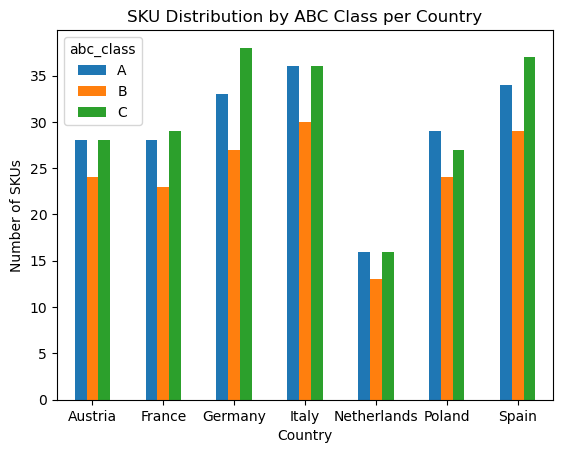

In [36]:
# Clustered bar graph showing distribution of the goods in ABC classes per country
plt.figure(figsize=(15,4))
abc_comparison.plot(kind='bar', stacked=False)
plt.title("SKU Distribution by ABC Class per Country")
plt.xlabel("Country")
plt.ylabel("Number of SKUs")
plt.xticks(rotation=0)
plt.savefig("SKU_distribution_abc.png")
plt.show()

**INSIGHTS**

**Germany** contributes highly by having more SKUs sales folowed by **Spain**, while **Netherland**s has the low sales.

There are more **C goods** than **A** and **B,** this causes the **Overstocking of C** and **understoking of A goods**

# Volatility (XYZ) by SKU

In [52]:
# Group by SKU and calculate mean and std of units sold
sku_stats = FMCG_df.groupby('sku_name')['units_sold'].agg(['mean','std']).reset_index()
sku_stats.head()

,sku_name,mean,std
0,BrandA Biscuits,84.247073,35.119650
1,BrandA Cheese,88.853699,35.153635
2,BrandA Chips,24.036115,10.046344
3,BrandA Chocolate,43.371598,25.204041
4,BrandA Cleaner,92.448858,45.592056


In [38]:
# Calculate coefficient of variation(cv)-( Dividing the standard deviation by the mean for each item)
sku_stats['cv'] = sku_stats['std'] / sku_stats['mean']
sku_stats

,sku_name,mean,std,cv
0,BrandA Biscuits,84.247073,35.119650,0.416865
1,BrandA Cheese,88.853699,35.153635,0.395635
2,BrandA Chips,24.036115,10.046344,0.417969
3,BrandA Chocolate,43.371598,25.204041,0.581119
4,BrandA Cleaner,92.448858,45.592056,0.493160
...,...,...,...,...
97,BrandF Soda,126.497336,68.803009,0.543909
98,BrandF Softener,29.713141,11.020407,0.370893
99,BrandF Toothpaste,104.398376,54.345511,0.520559
100,BrandF Water,97.387464,40.956221,0.420549


In [39]:
# Classify into X, Y, Z
def classify_xyz(cv):
    if cv <= 0.5:   # threshold can be adjusted
        return 'X'  # Low fluctuation,highly predictable (Very stable demand)
    elif cv <= 1.0:
        return 'Y'  # Moderate fluctuation (variable demand)
    else:
        return 'Z'  # Unpredictable variability (Irregular Demand)

sku_stats['xyz_class'] = sku_stats['cv'].apply(classify_xyz)

sku_stats

,sku_name,mean,std,cv,xyz_class
0,BrandA Biscuits,84.247073,35.119650,0.416865,X
1,BrandA Cheese,88.853699,35.153635,0.395635,X
2,BrandA Chips,24.036115,10.046344,0.417969,X
3,BrandA Chocolate,43.371598,25.204041,0.581119,Y
4,BrandA Cleaner,92.448858,45.592056,0.493160,X
...,...,...,...,...,...
97,BrandF Soda,126.497336,68.803009,0.543909,Y
98,BrandF Softener,29.713141,11.020407,0.370893,X
99,BrandF Toothpaste,104.398376,54.345511,0.520559,Y
100,BrandF Water,97.387464,40.956221,0.420549,X


In [44]:
# Total count of goods in the XYZ classes
sku_stats['xyz_class'].value_counts()

xyz_class
X    72
Y    30
Name: count, dtype: int64

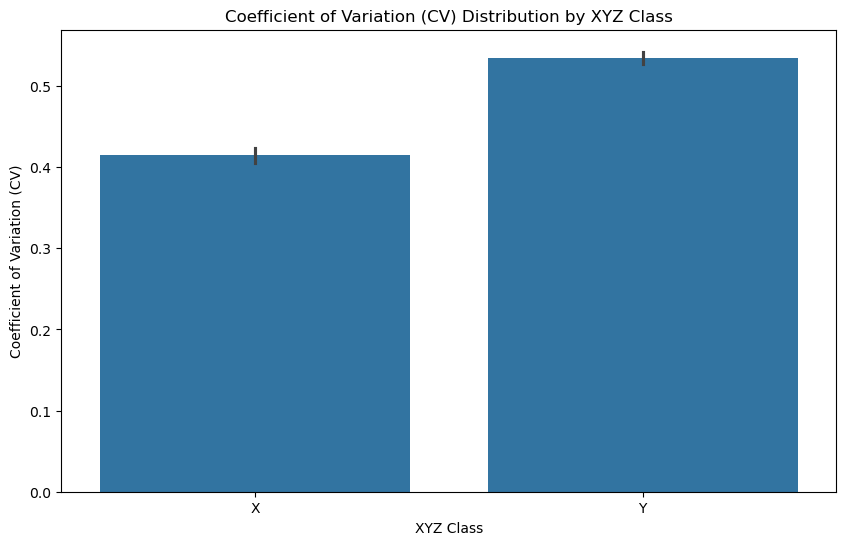

In [43]:
# Ploting a boxplot to show the XYZ Coefficient Variation distribution
plt.figure(figsize=(10,6))
sns.barplot(x='xyz_class', y='cv', data=sku_stats)
plt.title("Coefficient of Variation (CV) Distribution by XYZ Class")
plt.xlabel("XYZ Class")
plt.ylabel("Coefficient of Variation (CV)")
plt.savefig("cv_distribution_xyz.png")
plt.show()

**INSIGHTS**

We have  **72 X goods with 0.4 CV** meaning that they are **very stable**

**30 Y goods with a 0.55 CV** menaning they are **unstable goods**

# Correlate price, promotions, and volume

In [55]:
# Correlation matrix
corr_data = FMCG_df[['units_sold','list_price','discount_pct','promo_flag']]
corr_data

,units_sold,list_price,discount_pct,promo_flag
0,16,10.49,0.1,1
1,12,10.49,0.0,0
2,38,10.49,0.3,1
3,8,10.49,0.0,0
4,17,10.49,0.2,1
...,...,...,...,...
1099995,6,4.99,0.0,0
1099996,7,4.99,0.0,0
1099997,9,4.99,0.0,0
1099998,5,4.99,0.0,0


In [56]:
# Creating a correlation matrix
corr_matrix = FMCG_df[['units_sold','list_price','discount_pct','promo_flag']].corr()
corr_matrix

,units_sold,list_price,discount_pct,promo_flag
units_sold,1.000000,-0.082791,0.292777,0.295772
list_price,-0.082791,1.000000,-0.042847,-0.047780
discount_pct,0.292777,-0.042847,1.000000,0.924791
promo_flag,0.295772,-0.047780,0.924791,1.000000


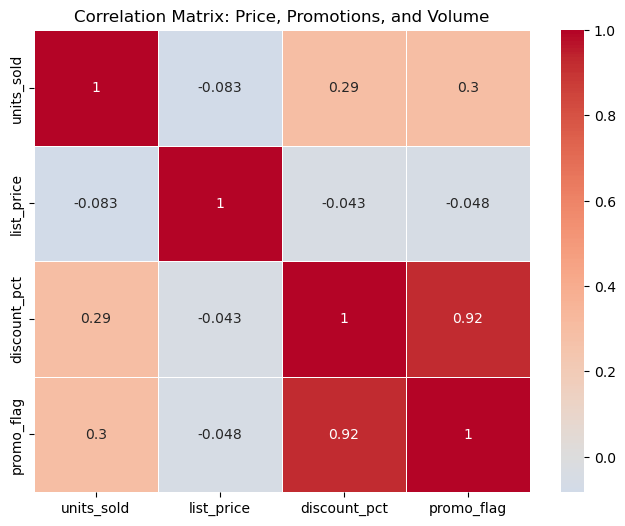

In [58]:
# Plot correlation matrix as heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Correlation Matrix: Price, Promotions, and Volume")
plt.savefig("Outputs/Correlation Matrix: Price, Promotions, and Volume.png")
plt.show()

**INSIGHTS**

 Strong **positive** correlation between **discount_pct** and **promo_flag** **(0.92)**; moderate positive correlation between **units_sold** and both **discount_pct (0.30)** and **promo_flag (0.30)**; weak negative correlation between **list_price** and other factors.

# Visualise seasonality (monthly & weekly patterns)

In [59]:
# Making a copy of the main df
FMCG_copy = FMCG_df
FMCG_copy

,date,year,month,day,weekofyear,weekday,is_weekend,is_holiday,temperature,rain_mm,store_id,country,city,channel,latitude,longitude,sku_id,sku_name,category,subcategory,brand,units_sold,list_price,discount_pct,promo_flag,gross_sales,net_sales,stock_on_hand,stock_out_flag,lead_time_days,supplier_id,purchase_cost,margin_pct
0,2021-01-01,2021,1,1,53,4,0,1,8.44,1.24,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,16,10.49,0.1,1,167.84,151.06,248,0,11,S008,7.53,0.182
1,2021-01-02,2021,1,2,53,5,1,0,12.61,1.12,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,12,10.49,0.0,0,125.88,125.88,238,0,6,S057,5.19,0.505
2,2021-01-03,2021,1,3,53,6,1,0,12.02,2.69,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,38,10.49,0.3,1,398.62,279.03,238,0,6,S017,5.59,0.168
3,2021-01-04,2021,1,4,1,0,0,0,7.76,4.65,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,8,10.49,0.0,0,83.92,83.92,216,0,7,S012,7.81,0.255
4,2021-01-05,2021,1,5,1,1,0,0,11.16,1.77,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,17,10.49,0.2,1,178.33,142.66,372,0,8,S038,7.62,0.073
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1099995,2022-09-08,2022,9,8,36,3,0,0,12.36,0.05,STORE0013,Netherlands,Amsterdam,Convenience,52.36231,4.95850,SKU0073,BrandA Softener,Home Care,Softener,BrandA,6,4.99,0.0,0,29.94,29.94,233,0,1,S023,3.07,0.384
1099996,2022-09-09,2022,9,9,36,4,0,0,12.51,5.96,STORE0013,Netherlands,Amsterdam,Convenience,52.36231,4.95850,SKU0073,BrandA Softener,Home Care,Softener,BrandA,7,4.99,0.0,0,34.93,34.93,219,0,7,S028,2.53,0.493
1099997,2022-09-10,2022,9,10,36,5,1,0,12.98,6.26,STORE0013,Netherlands,Amsterdam,Convenience,52.36231,4.95850,SKU0073,BrandA Softener,Home Care,Softener,BrandA,9,4.99,0.0,0,44.91,44.91,305,0,10,S027,2.46,0.507
1099998,2022-09-11,2022,9,11,36,6,1,0,16.72,0.20,STORE0013,Netherlands,Amsterdam,Convenience,52.36231,4.95850,SKU0073,BrandA Softener,Home Care,Softener,BrandA,5,4.99,0.0,0,24.95,24.95,282,0,9,S058,2.92,0.414


In [60]:
# Convert numeric month to month names
FMCG_copy['month'] = pd.to_datetime(FMCG_copy['month'], format='%m').dt.strftime('%B')
FMCG_copy

,date,year,month,day,weekofyear,weekday,is_weekend,is_holiday,temperature,rain_mm,store_id,country,city,channel,latitude,longitude,sku_id,sku_name,category,subcategory,brand,units_sold,list_price,discount_pct,promo_flag,gross_sales,net_sales,stock_on_hand,stock_out_flag,lead_time_days,supplier_id,purchase_cost,margin_pct
0,2021-01-01,2021,January,1,53,4,0,1,8.44,1.24,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,16,10.49,0.1,1,167.84,151.06,248,0,11,S008,7.53,0.182
1,2021-01-02,2021,January,2,53,5,1,0,12.61,1.12,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,12,10.49,0.0,0,125.88,125.88,238,0,6,S057,5.19,0.505
2,2021-01-03,2021,January,3,53,6,1,0,12.02,2.69,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,38,10.49,0.3,1,398.62,279.03,238,0,6,S017,5.59,0.168
3,2021-01-04,2021,January,4,1,0,0,0,7.76,4.65,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,8,10.49,0.0,0,83.92,83.92,216,0,7,S012,7.81,0.255
4,2021-01-05,2021,January,5,1,1,0,0,11.16,1.77,STORE0001,Germany,Berlin,Hypermarket,52.52586,13.39071,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,17,10.49,0.2,1,178.33,142.66,372,0,8,S038,7.62,0.073
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1099995,2022-09-08,2022,September,8,36,3,0,0,12.36,0.05,STORE0013,Netherlands,Amsterdam,Convenience,52.36231,4.95850,SKU0073,BrandA Softener,Home Care,Softener,BrandA,6,4.99,0.0,0,29.94,29.94,233,0,1,S023,3.07,0.384
1099996,2022-09-09,2022,September,9,36,4,0,0,12.51,5.96,STORE0013,Netherlands,Amsterdam,Convenience,52.36231,4.95850,SKU0073,BrandA Softener,Home Care,Softener,BrandA,7,4.99,0.0,0,34.93,34.93,219,0,7,S028,2.53,0.493
1099997,2022-09-10,2022,September,10,36,5,1,0,12.98,6.26,STORE0013,Netherlands,Amsterdam,Convenience,52.36231,4.95850,SKU0073,BrandA Softener,Home Care,Softener,BrandA,9,4.99,0.0,0,44.91,44.91,305,0,10,S027,2.46,0.507
1099998,2022-09-11,2022,September,11,36,6,1,0,16.72,0.20,STORE0013,Netherlands,Amsterdam,Convenience,52.36231,4.95850,SKU0073,BrandA Softener,Home Care,Softener,BrandA,5,4.99,0.0,0,24.95,24.95,282,0,9,S058,2.92,0.414


In [61]:
# Order months correctly
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
FMCG_copy['month'] = pd.Categorical(FMCG_copy['month'], categories=month_order, ordered=True)

In [62]:
# Aggregate units sold by month across all years
monthly_sales1 = FMCG_copy.groupby('year')['units_sold'].sum().reset_index()
monthly_sales1

,year,units_sold
0,2021,21716142
1,2022,21710847
2,2023,21688993


In [67]:
# Aggregate units sold by month across all years
monthly_sales = FMCG_copy[monthly_features]
monthly_sales

,year,month,units_sold,net_sales
0,2021,January,16,151.06
1,2021,January,12,125.88
2,2021,January,38,279.03
3,2021,January,8,83.92
4,2021,January,17,142.66
...,...,...,...,...
1099995,2022,September,6,29.94
1099996,2022,September,7,34.93
1099997,2022,September,9,44.91
1099998,2022,September,5,24.95


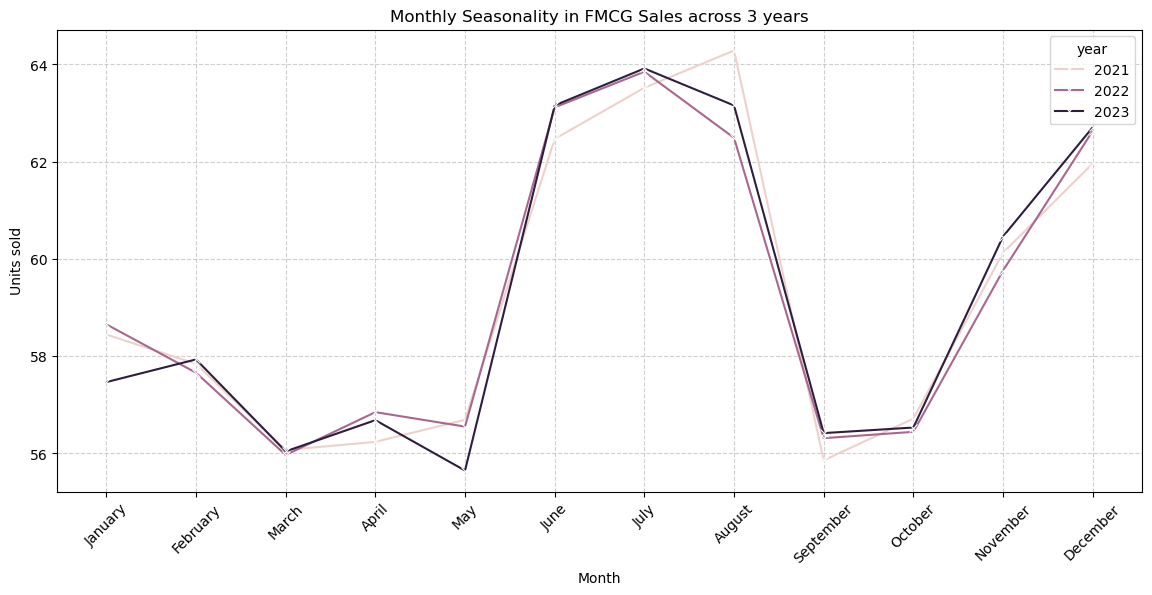

In [72]:
# Plot a graph of monthly sales(units sold) across the 3 years
plt.figure(figsize=(14,6))
sns.lineplot(x='month', y= 'units_sold',data= monthly_sales,hue='year',marker='x',errorbar=None,color = "viridis")
plt.xlabel('Month')
plt.ylabel('Units sold')
plt.title('Monthly Seasonality in FMCG Sales across 3 years')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig("Outputs/Monthly Seasonality in FMCG Sales across 3 years.png")
plt.show()

**INSIGHTS**

There has been a decrease in the total units sold from 2021 having the highest sales and 2023 having the lowest.

The peak sales starts from **May** and rises in **June and July** (summer) but drops drastically in **September** (Fall) and starts to rise again from **November and December** (Winter and Christmas)


In [76]:
# Aggregate units sold weekly across all years
weekly_sales = FMCG_copy.groupby(['weekday','year'])['units_sold'].sum().reset_index()
weekly_sales['weekday'] = weekly_sales['weekday'] + 1
weekly_sales['units_sold_in_millions'] = weekly_sales['units_sold']/1000000
weekly_sales

,weekday,year,units_sold,units_sold_in_millions
0,1,2021,2917251,2.917251
1,1,2022,2921276,2.921276
2,1,2023,2930495,2.930495
3,2,2021,2933745,2.933745
4,2,2022,2932304,2.932304
5,2,2023,2924737,2.924737
6,3,2021,2929656,2.929656
7,3,2022,2936616,2.936616
8,3,2023,2914507,2.914507
9,4,2021,2935318,2.935318


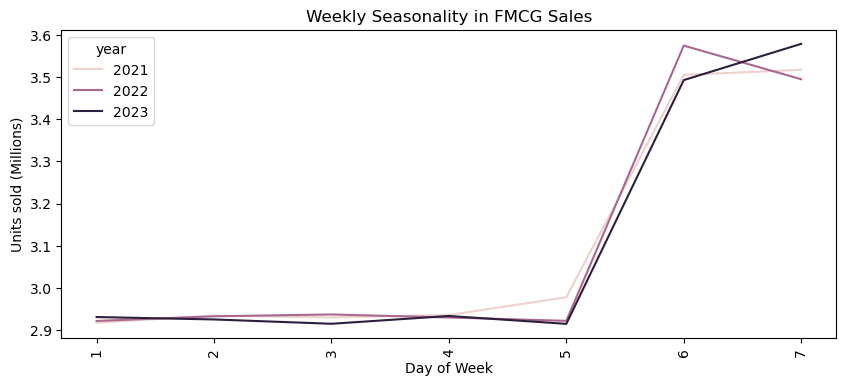

In [78]:
# Plotting a line chart for the weekly sales 
plt.figure(figsize=(10,4))
sns.lineplot(x='weekday', y= 'units_sold_in_millions',data= weekly_sales, hue='year',color = "ocean")
plt.xlabel('Day of Week')
plt.ylabel('Units sold (Millions)')
plt.title('Weekly Seasonality in FMCG Sales')
plt.xticks(rotation=90)

plt.savefig("Outputs/Weekly Seasonality in FMCG Sales.png")
plt.show()

**INSIGHTS**

**Saturday and Sundays**  (Weekend) usually have the highest sales, since people are doing their weekly shoping at that time.